# Environment

## Imports

In [8]:
import pyranges1 as pr
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from collections import Counter
import itertools

## Global variables

## Load data

Load peaks

In [11]:
filepath = "data/peaks/newlvl5_consensus_peaks.bed"
peaks = pr.read_bed(filepath)
peaks["celltypes"] = peaks["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).apply(lambda x: ",".join(set(x.split(","))))
peaks["ct_count"] = peaks["celltypes"].apply(lambda x: int(len(set(x.split(",")))))
peaks.head()

,Chromosome,Start,End,Name,Score,Strand,celltypes,ct_count
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,radial_glia_diencephalon,1
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,wolffian_duct_epithelium,1
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,megakaryocyte_progenitor,1
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,megakaryocyte_progenitor,1


Load cell type annotations

In [7]:
annotation = pd.read_csv("data/annotations/we_new_lvl5.csv")
annotation["celltype"] = annotation["celltype"].str.replace(" ", "_").str.lower()
annotation.head()

,sample_id,barcode,celltype
0,WS_wEMB13386878,ATGGACAAGACAGGTA-1,chondrocyte_precursor
1,WS_wEMB13386878,TCAAGTATCTGTGAGT-1,yolk_sac-derived_trem2+_macrophage
2,WS_wEMB13386878,CGGCTCACAGTTATGT-1,early_endothelium
3,WS_wEMB13386878,ATTTGCGCACTAAGCC-1,fibroblast_progenitors_pdgfra+zic1+fibin+
4,WS_wEMB13386878,CCTTCAATCAAGCTTA-1,monocyte


# Analyze peaks

## Number of cells per cell type

/tmp/ipykernel_2992567/3727745538.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


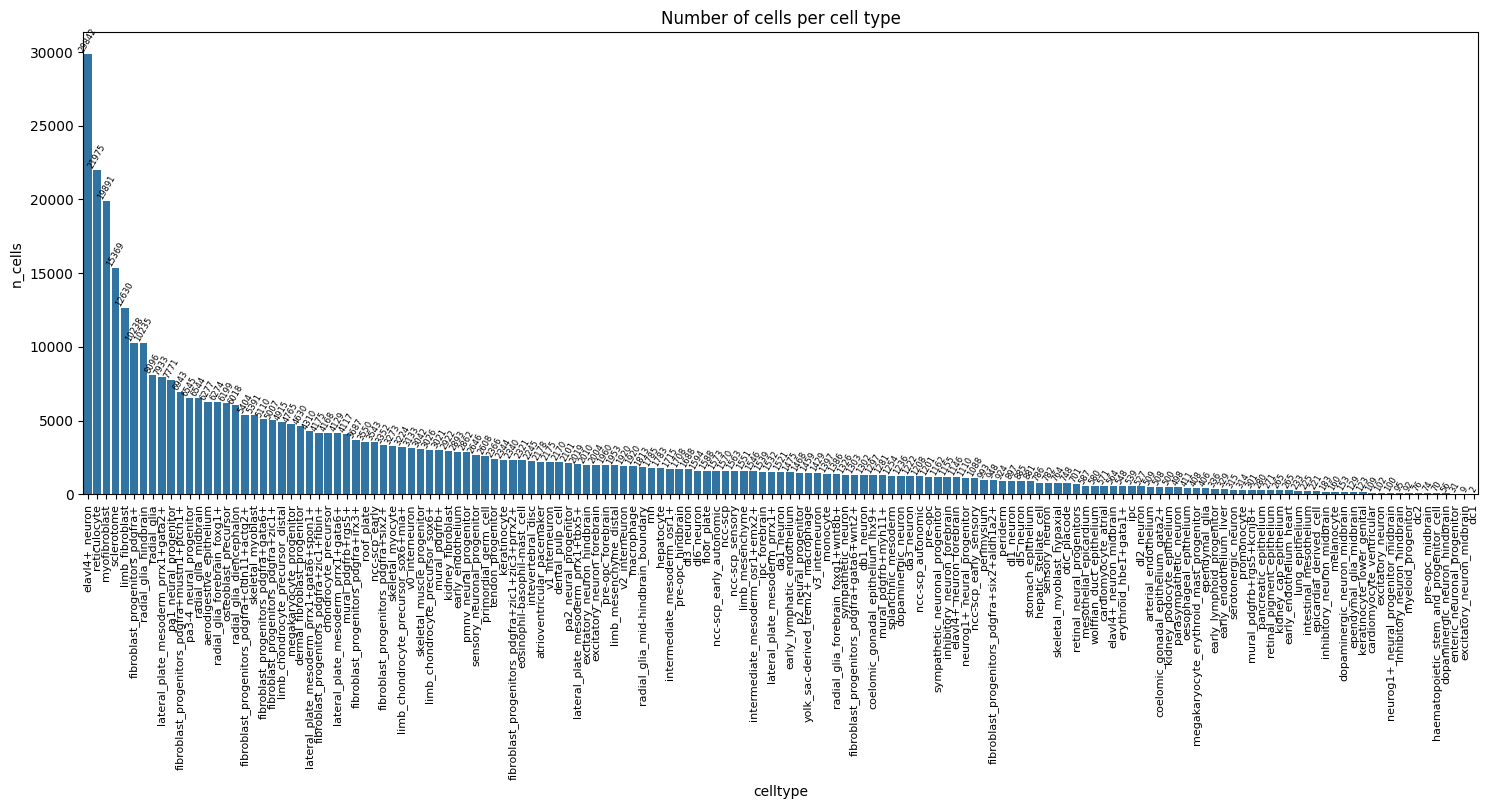

In [54]:
fig, ax = plt.subplots(figsize=(18, 6))
cell_counts = annotation.celltype.str.replace(" ", "_").str.lower().value_counts().to_frame(name="n_cells")

sns.barplot(cell_counts, x=cell_counts.index, y="n_cells", ax=ax)
ax.set_title("Number of cells per cell type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.bar_label(ax.containers[0], fontsize=6, rotation=60);
plt.show()

## Peak counts

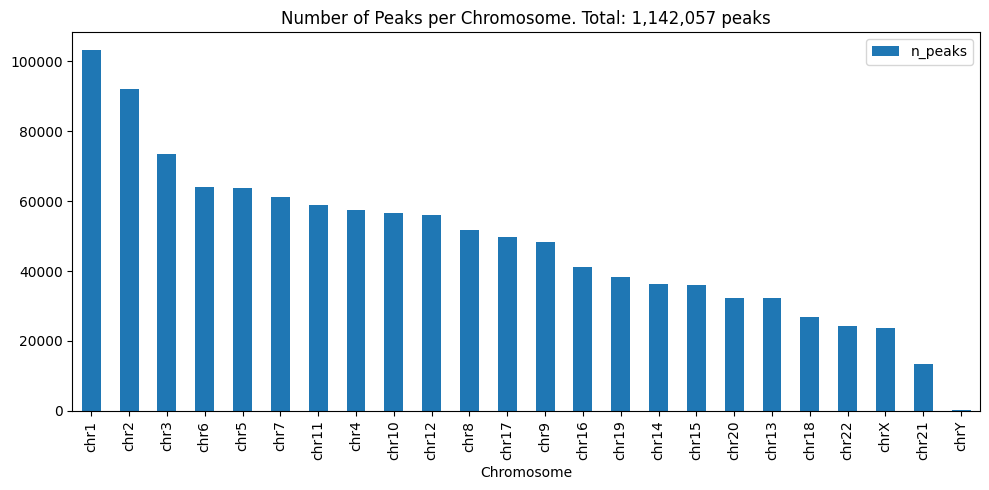

In [46]:
peak_number_by_chr = peaks.Chromosome.value_counts().to_frame(name="n_peaks").reset_index()
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
cat_type = pd.CategoricalDtype(categories=chrom_order, ordered=True)
peak_number_by_chr['Chromosome'] = peak_number_by_chr['Chromosome'].astype(cat_type)

peak_number_by_chr.plot.bar(x='Chromosome', y='n_peaks', figsize=(10, 5))
plt.title(f'Number of Peaks per Chromosome. Total: {peaks.shape[0]:,} peaks')
plt.tight_layout()

Let's take a look at peak numbers per cell type

In [34]:
flat = list(itertools.chain.from_iterable([x.split(",") for x in peaks["celltypes"].tolist()]))
counts = Counter(flat)
n_peaks_celltype = pd.DataFrame(counts.most_common(), columns=["celltype", "n_peaks"]).set_index("celltype")

/tmp/ipykernel_2992567/2239745134.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


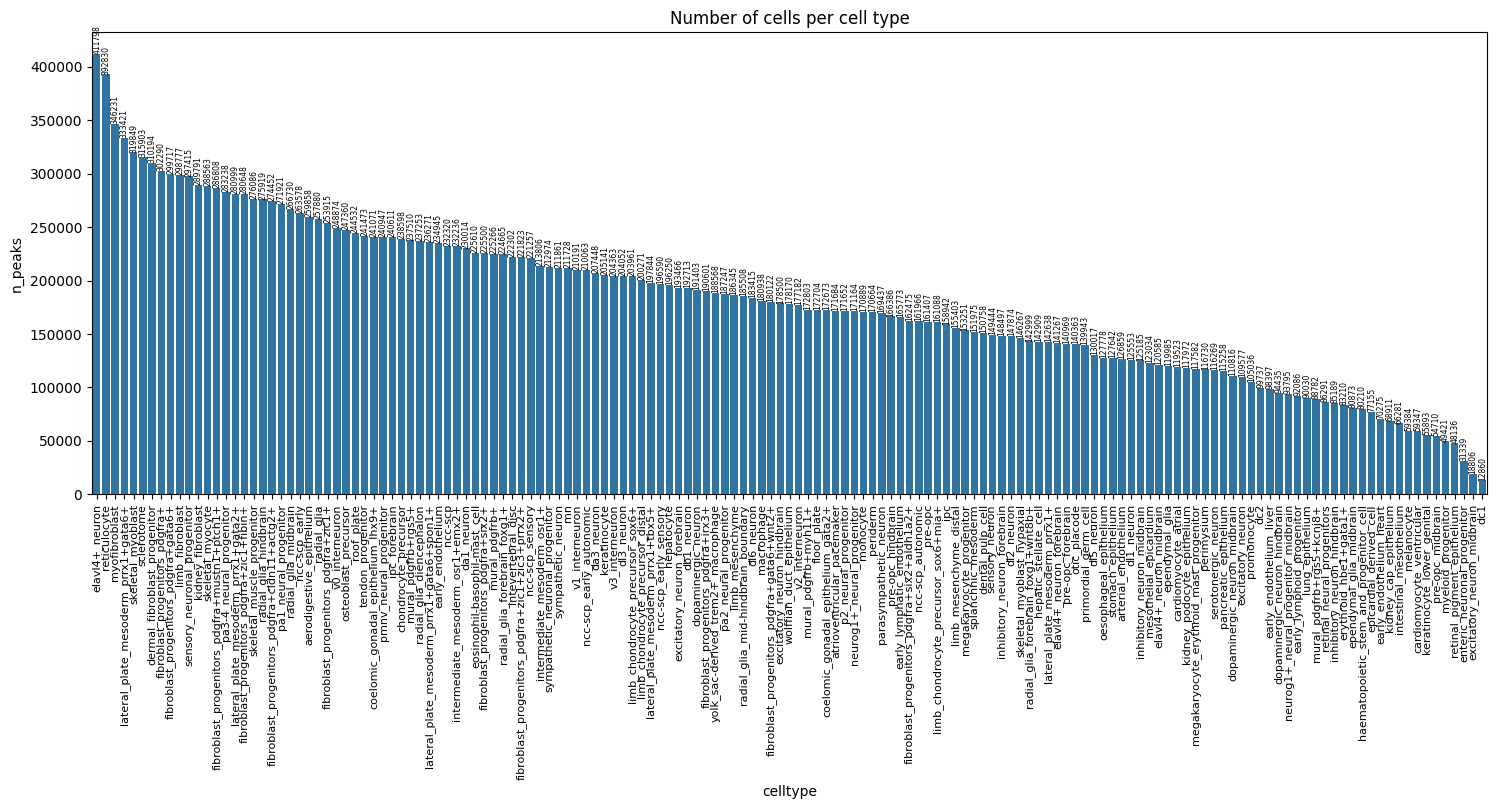

In [50]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.barplot(n_peaks_celltype.reset_index(), x="celltype", y="n_peaks", ax=ax)
ax.set_title("Number of cells per cell type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.bar_label(ax.containers[0], fontsize=5.5, rotation=90);
plt.show()

Let's also take a look at peak numbers per chromosome

In [59]:
celltypes = cell_counts.index.tolist()

In [ ]:
peak_number_by_chr = peaks.Chromosome.value_counts().to_frame(name="n_peaks").reset_index()
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
cat_type = pd.CategoricalDtype(categories=chrom_order, ordered=True)
peak_number_by_chr['Chromosome'] = peak_number_by_chr['Chromosome'].astype(cat_type)

In [70]:
celltypes = cell_counts.index.tolist()

ct_peak_numbers = list()
for ct in tqdm(celltypes, desc="Calculating peaks per cell type"):
    subset = peaks[peaks.celltypes.str.contains(ct, regex=False)]
    peak_number_by_chr = subset.Chromosome.value_counts().to_frame(name=ct)
    ct_peak_numbers.append(peak_number_by_chr)

ct_peak_numbers_df = pd.concat(ct_peak_numbers, axis=1).fillna(0)
ct_peak_numbers_df

Calculating peaks per cell type:   0%|          | 0/151 [00:00<?, ?it/s]

,elavl4+_neuron,reticulocyte,myofibroblast,sclerotome,limb_fibroblast,fibroblast_progenitors_pdgfra+,radial_glia_hindbrain,radial_glia,lateral_plate_mesoderm_prrx1+gata2+,pa1_neural_progenitor,...,neurog1+_neural_progenitor_midbrain,inhibitory_neuron_hindbrain,myeloid_progenitor,dc2,pre-opc_midbrain,haematopoietic_stem_and_progenitor_cell,dopaminergic_neuron_hindbrain,enteric_neuronal_progenitor,excitatory_neuron_midbrain,dc1
Chromosome,,,,,,,,,,,,,,,,,,,,,
chr1,41800,37458,33609,29441,28923,53826,25853,41961,26742,26383,...,9197,8344,5077,9703,5438,8312,9322,3152,1975,1258
chr2,32806,28667,24252,22986,21234,42414,19743,32634,20973,18463,...,6630,5935,3200,6805,3798,5202,6634,2138,1263,904
chr3,24867,21927,18681,17425,16098,33481,15087,25481,15491,14253,...,4756,4251,2330,5266,2670,3951,4868,1624,1065,744
chr11,24696,22097,19787,17523,17009,31379,15486,24858,15384,15967,...,5291,4956,2794,5543,3078,4574,5439,1801,1051,725
chr17,24304,22260,21129,18208,17770,30821,15728,24305,15390,16556,...,5590,5167,3397,6630,3419,5482,5675,2065,1187,871
chr7,23160,20472,17907,16693,15565,29583,14562,23758,14947,14032,...,4844,4376,2470,4826,2739,3972,4916,1525,914,613
chr6,22515,19671,16500,16157,14153,29395,13897,22679,14179,12573,...,4590,3916,2455,5370,2802,3979,4520,1560,1052,705
chr5,22111,19225,16178,15255,14097,28993,13092,22233,13830,12434,...,4515,3883,2210,4249,2519,3308,4509,1413,847,594
chr10,22002,19425,16864,15560,14795,28008,12650,20895,13730,12613,...,4317,4023,2123,4491,2448,3528,4339,1326,768,572


I want to take a look at peaks combined from several cell types

In [ ]:
celltypes = set(','.join(peaks[key]["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).to_list()).split(","))

In [ ]:
peaks[key]["celltypes"] = peaks[key]["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).apply(lambda x: ",".join(set(x.split(","))))
peaks[key]["ct_count"] = peaks[key]["celltypes"].apply(lambda x: int(len(set(x.split(",")))))
peaks[key].head()

,Chromosome,Start,End,Name,Score,Strand,celltypes,ct_count
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,radial_glia_diencephalon,1
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,wolffian_duct_epithelium,1
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,megakaryocyte_progenitor,1
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,megakaryocyte_progenitor,1


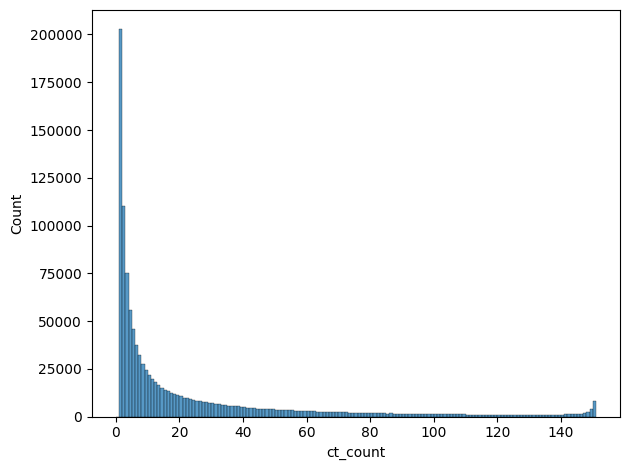

In [ ]:
sns.histplot(peaks[key].ct_count, bins=np.arange(0, 152, 1))
plt.tight_layout()

In [ ]:
print(f"Number of peaks in {key} that are present in 1 cell type: {(peaks[key]['ct_count'] == 1).sum()}")
print(f"Number of peaks in {key} that are present in 3 or fewer cell types: {(peaks[key]['ct_count'] <= 3).sum()}")
print(f"Number of peaks in {key} that are present in more than 3 cell types: {(peaks[key]['ct_count'] > 3).sum()}")

Number of peaks in lvl5 that are present in 1 cell type: 202682
Number of peaks in lvl5 that are present in 3 or fewer cell types: 388195
Number of peaks in lvl5 that are present in more than 3 cell types: 753862


Let's take a look at number peaks per celltype

In [ ]:
from collections import Counter
import itertools

# create a flat list of all cell types and count the number of peaks per cell type
flat = list(itertools.chain.from_iterable([x.split(",") for x in peaks[key]["celltypes"].tolist()]))
counts = Counter(flat)
peak_counts = pd.DataFrame(counts.most_common(), columns=["celltype", "n_peaks"]).set_index("celltype")

# count the number of peaks that are unique to each cell type (i.e. present in only 1 cell type)
unique_peak_counts = peaks[key][peaks[key]['ct_count'] == 1].celltypes.value_counts().to_frame(name="n_unique")

peak_counts = pd.concat([peak_counts, unique_peak_counts, cell_counts], axis=1).fillna(0).reset_index(names="celltype").sort_values("n_cells", ascending=False)
peak_counts["frc_unique"] = peak_counts["n_unique"] / peak_counts["n_peaks"]
peak_counts

,celltype,n_peaks,n_unique,n_cells,frc_unique
0,elavl4+_neuron,411798,138,29842,0.000335
1,reticulocyte,392830,170,21975,0.000433
2,myofibroblast,346231,165,19891,0.000477
5,sclerotome,315903,2460,15369,0.007787
9,limb_fibroblast,298777,738,12630,0.002470
...,...,...,...,...,...
137,haematopoietic_stem_and_progenitor_cell,80210,4040,70,0.050368
128,dopaminergic_neuron_hindbrain,94435,3548,56,0.037571
148,enteric_neuronal_progenitor,31339,494,31,0.015763
149,excitatory_neuron_midbrain,18806,354,9,0.018824


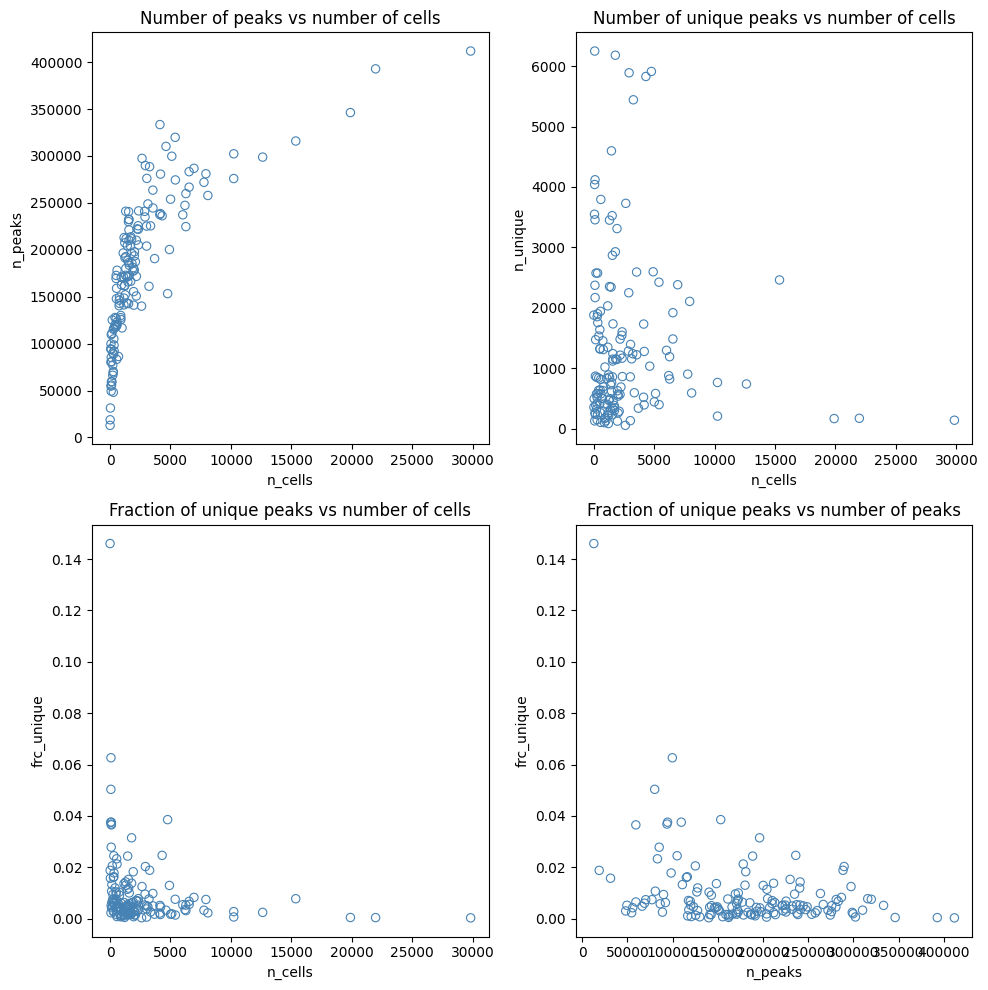

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

scatter_kws = dict(facecolors='none', edgecolors='steelblue', linewidth=0.8)

sns.scatterplot(peak_counts, x="n_cells", y="n_peaks", ax=axes[0, 0], **scatter_kws)
axes[0, 0].set_title("Number of peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_cells", y="n_unique", ax=axes[0, 1], **scatter_kws)
axes[0, 1].set_title("Number of unique peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_cells", y="frc_unique", ax=axes[1, 0], **scatter_kws)
axes[1, 0].set_title("Fraction of unique peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_peaks", y="frc_unique", ax=axes[1, 1], **scatter_kws)
axes[1, 1].set_title("Fraction of unique peaks vs number of peaks")

plt.tight_layout()

## Basic stats

### Peak length distribution

Peaks that we called with `pyCistopic` all have a length of 500bp, which is the default value for the `peak_extension` parameter. Let's take a look at the length distribution of the SCREEN peaks

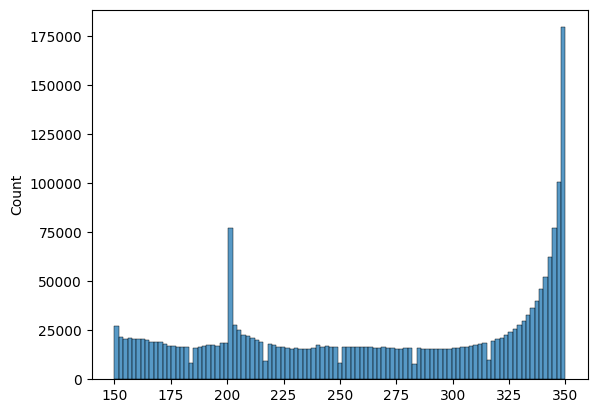

In [7]:
sns.histplot(screen.End - screen.Start)
plt.show()

### Peak counts

The number of peaks called by each approach is as follows

Text(0.5, 1.0, 'Number of peaks per chromosome for each approach')

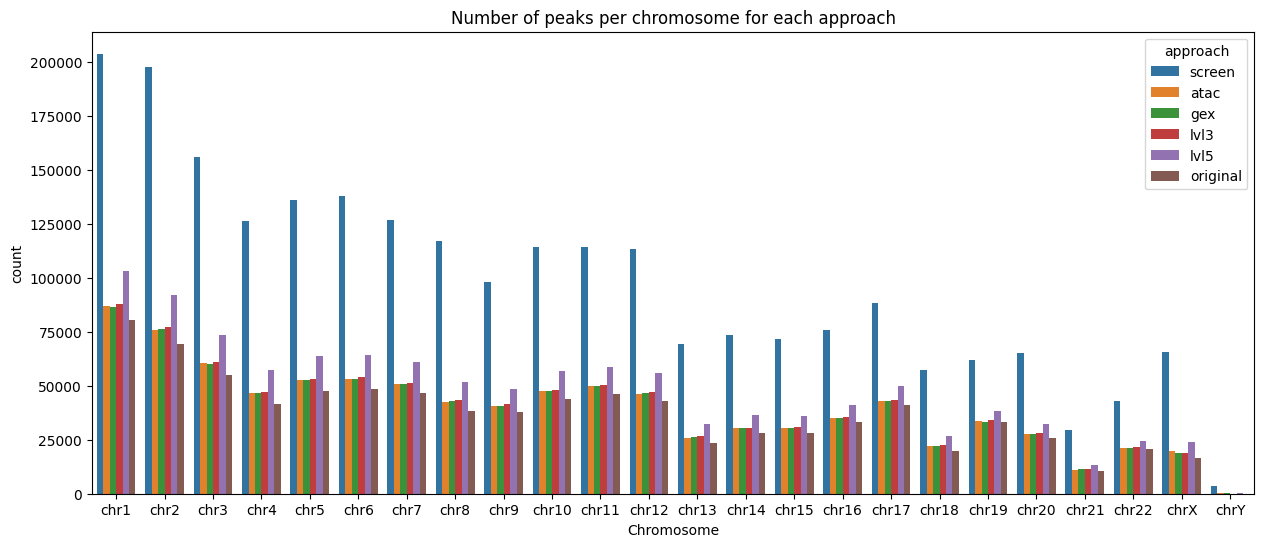

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))

# Count the number of peaks per chromosome for each approach
peak_counts_bychr = pd.concat([peaks[key].Chromosome.value_counts().to_frame(name=key) for key in peaks.keys()], axis=1)
peak_counts_bychr_unstacked = (
    peak_counts_bychr
    .unstack()
    .to_frame(name="count")
    .reset_index()
    .rename(columns={"level_0": "approach"})
)

# The chromosomes are currently sorted in alphanumeric order, which is not ideal. Let's sort them in natural order
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
cat_type = pd.CategoricalDtype(categories=chrom_order, ordered=True)
peak_counts_bychr_unstacked['Chromosome'] = peak_counts_bychr_unstacked['Chromosome'].astype(cat_type)
peak_counts_bychr_unstacked = peak_counts_bychr_unstacked.sort_values('Chromosome')

sns.barplot(
    peak_counts_bychr_unstacked,
    x="Chromosome",
    y="count",
    hue="approach",
    hue_order=["screen", "atac", "gex", "lvl3", "lvl5", "original"],
    ax=ax
)

ax.set_title("Number of peaks per chromosome for each approach")

We can notice that the number of peaks called for `lvl5` annotation is higher compared to other approaches. We will need to investigate if those peaks are actually relevant. On the other hand, we can see that the number of peaks for separate chromosomes is highly correlated between the different approaches, which is reassuring

<Axes: >

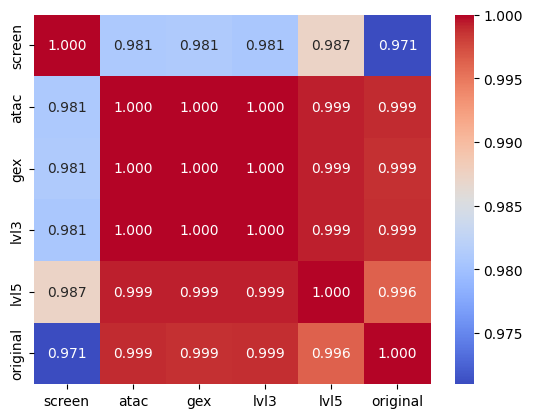

In [9]:
sns.heatmap(peak_counts_bychr.corr(), annot=True, cmap="coolwarm", fmt=".3f")

### Peak overlaps

Now we can look at how many peaks from each set overlap with peaks from the other sets, using a minimum overlap threshold of 30 bp

In [10]:
a = np.array([1, 2, 3])
b = np.array([2, 3, 4])
np.min([a, b], axis=0)

array([1, 2, 3])

In [11]:
overlap_threshold = 30
counts = list()
fractions = list()
overlap_lengths = list()


for key1, df1 in tqdm(peaks.items()):
    key1_counts = list()
    key1_fractions = list()
    key1_overlap_lengths = list()
    key1_overlap_fractions = list()
    for key2, df2 in peaks.items():
        if key1 == key2:
            key1_counts.append(df1.shape[0])
            key1_fractions.append(1)
            key1_overlap_lengths.append((df1.End - df1.Start).mean())
            key1_overlap_fractions.append(1)
        else:
            # find overlaps between df1 and df2
            overlaps = df1.intersect_overlaps(df2)
            # filter overlaps by length
            overlaps["length"] = overlaps.End - overlaps.Start
            overlaps = overlaps[overlaps["length"] >= overlap_threshold]
            # remove duplicate overlaps (i.e. multiple peaks in df2 overlapping the same peak in df1)
            overlaps = overlaps[~overlaps.index.duplicated()]
            # save the number of overlaps and the fraction of peaks in df1 that overlap with peaks in df2
            key1_counts.append(overlaps.shape[0])
            key1_fractions.append(overlaps.shape[0] / df1.shape[0])
            key1_overlap_lengths.append((overlaps.End - overlaps.Start).mean())
    counts.append(key1_counts)
    fractions.append(key1_fractions)
    overlap_lengths.append(key1_overlap_lengths)

# create a dataframe from the counts and fractions
counts_df = pd.DataFrame(counts, columns=peaks.keys(), index=peaks.keys())
fractions_df = pd.DataFrame(fractions, columns=peaks.keys(), index=peaks.keys())
overlap_lengths_df = pd.DataFrame(overlap_lengths, columns=peaks.keys(), index=peaks.keys())

  0%|          | 0/6 [00:00<?, ?it/s]

First, let's look at the number and fraction of peaks that overlap between each pair of approaches

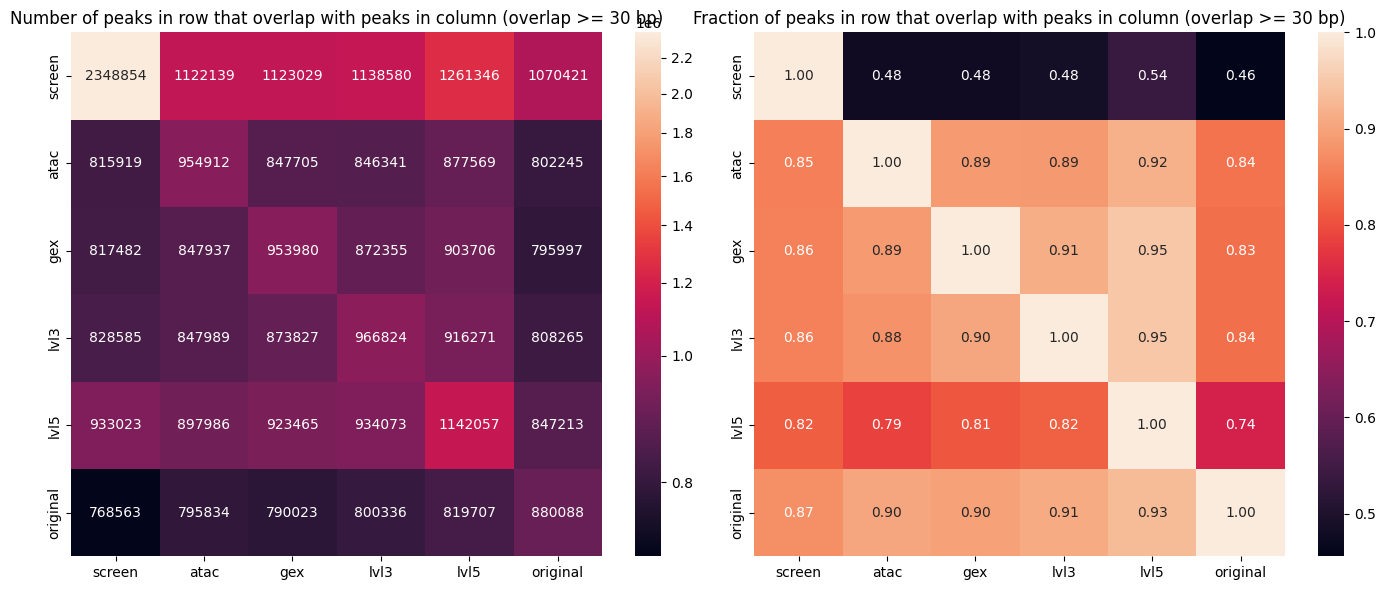

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
norm = colors.PowerNorm(0.5, vmin=None, vmax=None, clip=False)

sns.heatmap(counts_df, annot=True, fmt="d", ax=ax1, norm=norm)
sns.heatmap(fractions_df, annot=True, fmt=".2f", ax=ax2)

ax1.set_title(f"Number of peaks in row that overlap with peaks in column (overlap >= {overlap_threshold} bp)")
ax2.set_title(f"Fraction of peaks in row that overlap with peaks in column (overlap >= {overlap_threshold} bp)")
plt.tight_layout()
plt.show()

Second, let's take a look at the distributions of the lengths of the overlaps between peaks from each pair of approaches

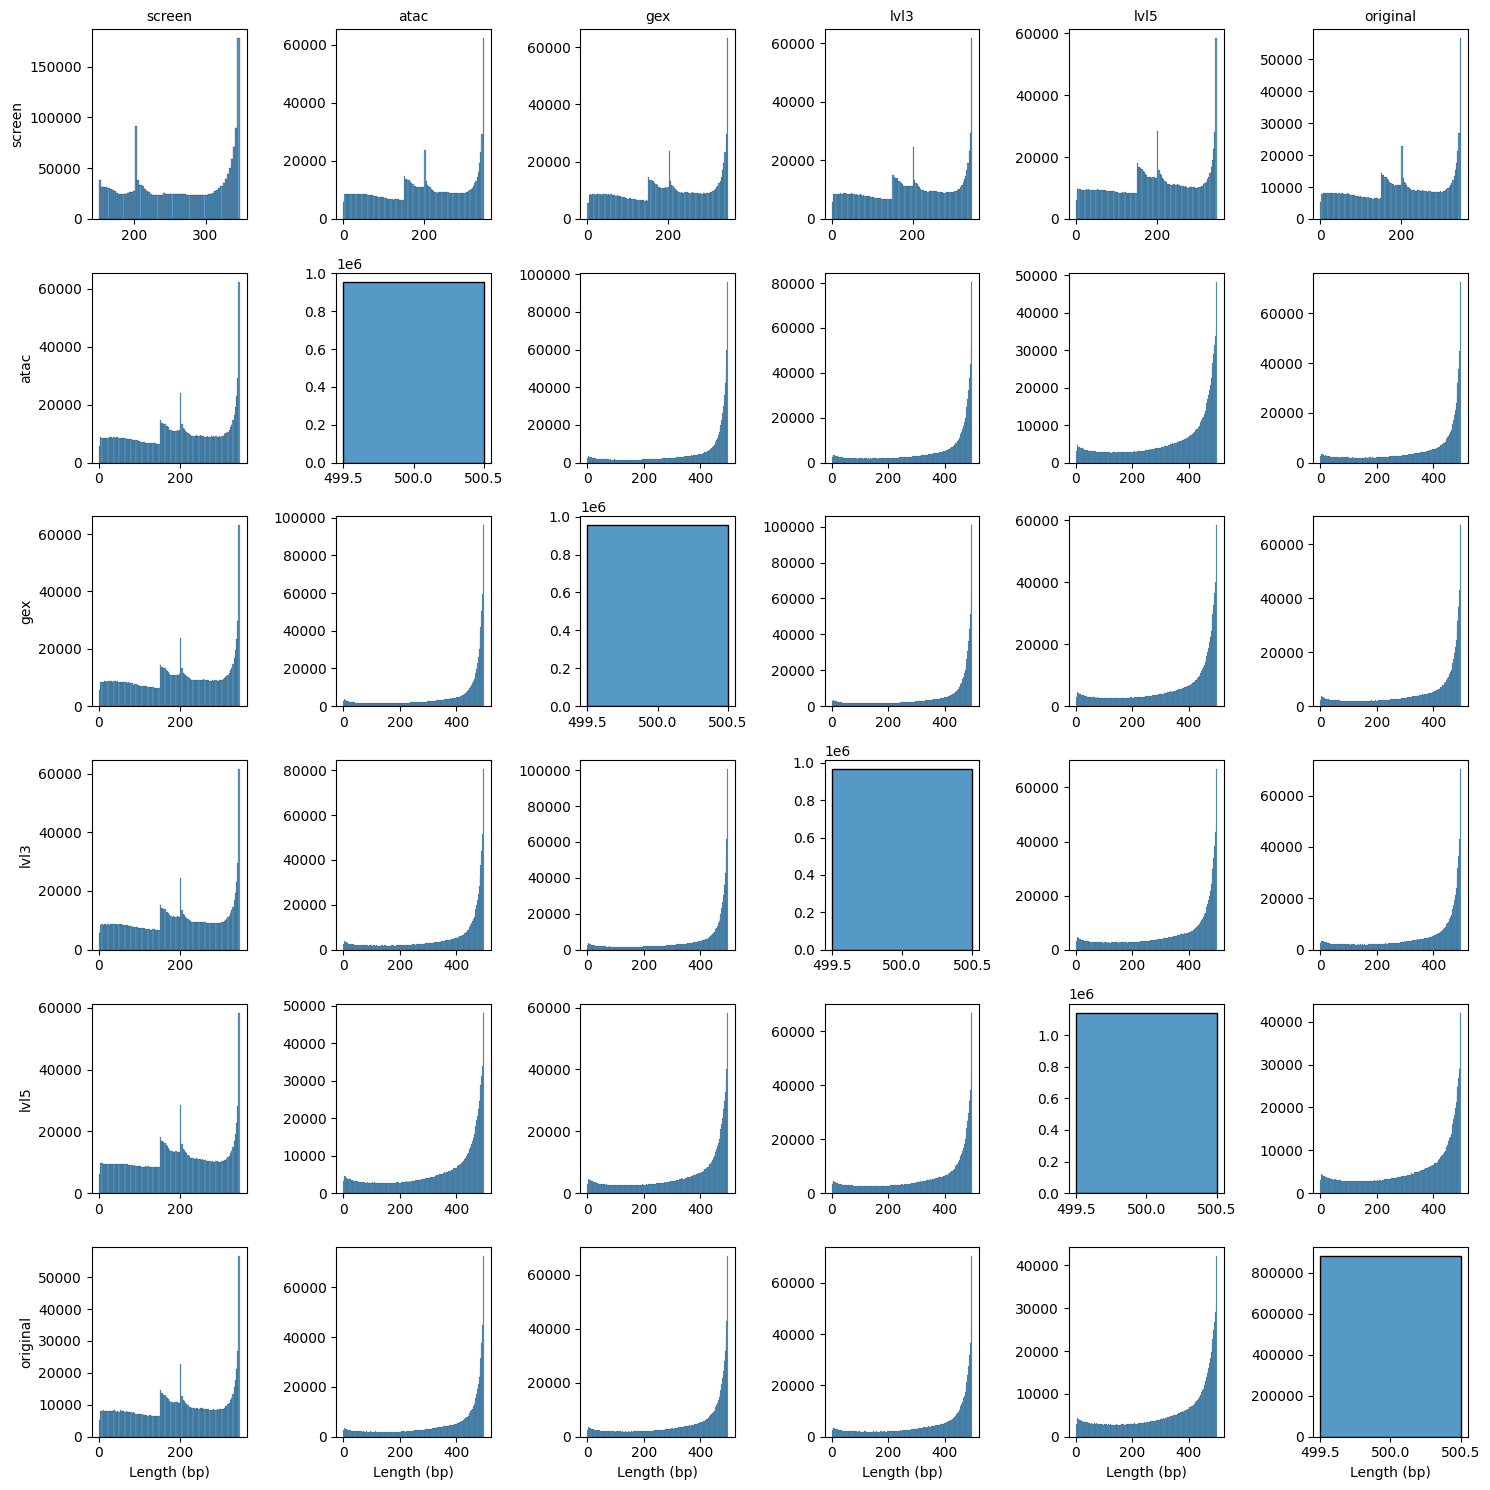

In [13]:
fig, axes = plt.subplots(len(peaks), len(peaks), figsize=(15, 15))
keys = list(peaks.keys())

for i, (key1, df1) in enumerate(peaks.items()):
    for j, (key2, df2) in enumerate(peaks.items()):
        ax = axes[i, j]
        
        # find overlaps between df1 and df2
        if key1 == key2:
            overlap_lengths = df1.End - df1.Start
            bins = 1 if i != 0 else np.arange(150, 350, 3)
        else:
            overlaps = df1.intersect_overlaps(df2)
            overlaps["length"] = overlaps.End - overlaps.Start
            overlap_lengths = overlaps["length"]
            bins = np.arange(0, 350, 3) if i == 0 or j == 0 else np.arange(0, 500, 3)
        
        # plot the distribution of overlap lengths
        sns.histplot(overlap_lengths, ax=ax, bins=bins)

        # only show axis labels on edges
        ax.set_xlabel("Length (bp)" if i == len(peaks) - 1 else "")
        ax.set_ylabel("Count" if j == 0 else "")
        
        # only show row/col headers on edges
        if i == 0:
            ax.set_title(keys[j], fontsize=10)
        else:
            ax.set_title("")
        if j == 0:
            ax.set_ylabel(keys[i], fontsize=10)

plt.tight_layout()

## LVL5 peaks

In [14]:
key = "lvl5"

Let's take a look at the distribution of number of cells for cell types

/tmp/ipykernel_3798743/1622440495.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


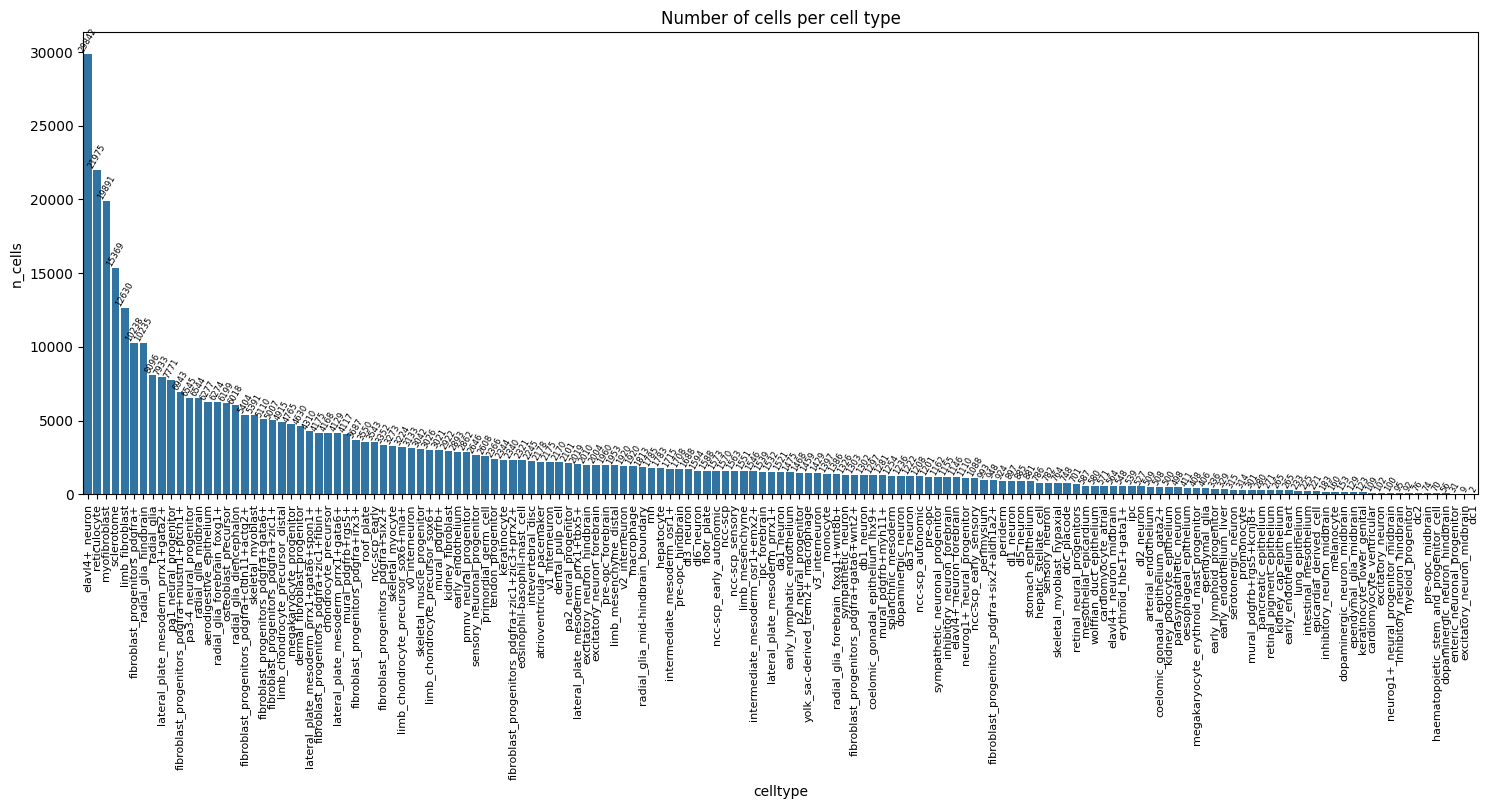

In [15]:
fig, ax = plt.subplots(figsize=(18, 6))
cell_counts = annotations[key].celltype.str.replace(" ", "_").str.lower().value_counts().to_frame(name="n_cells")

sns.barplot(cell_counts, x=cell_counts.index, y="n_cells", ax=ax)
ax.set_title("Number of cells per cell type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.bar_label(ax.containers[0], fontsize=6, rotation=60);
plt.show()

I want to take a look at peaks combined from several cell types

In [16]:
celltypes = set(','.join(peaks[key]["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).to_list()).split(","))

In [17]:
peaks[key]["celltypes"] = peaks[key]["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).apply(lambda x: ",".join(set(x.split(","))))
peaks[key]["ct_count"] = peaks[key]["celltypes"].apply(lambda x: int(len(set(x.split(",")))))
peaks[key].head()

,Chromosome,Start,End,Name,Score,Strand,celltypes,ct_count
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,radial_glia_diencephalon,1
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,wolffian_duct_epithelium,1
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,megakaryocyte_progenitor,1
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,megakaryocyte_progenitor,1


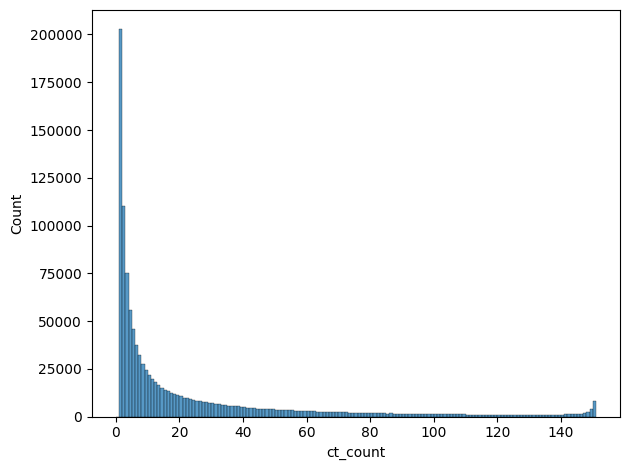

In [18]:
sns.histplot(peaks[key].ct_count, bins=np.arange(0, 152, 1))
plt.tight_layout()

In [19]:
print(f"Number of peaks in {key} that are present in 1 cell type: {(peaks[key]['ct_count'] == 1).sum()}")
print(f"Number of peaks in {key} that are present in 3 or fewer cell types: {(peaks[key]['ct_count'] <= 3).sum()}")
print(f"Number of peaks in {key} that are present in more than 3 cell types: {(peaks[key]['ct_count'] > 3).sum()}")

Number of peaks in lvl5 that are present in 1 cell type: 202682
Number of peaks in lvl5 that are present in 3 or fewer cell types: 388195
Number of peaks in lvl5 that are present in more than 3 cell types: 753862


Let's take a look at number peaks per celltype

In [20]:
from collections import Counter
import itertools

# create a flat list of all cell types and count the number of peaks per cell type
flat = list(itertools.chain.from_iterable([x.split(",") for x in peaks[key]["celltypes"].tolist()]))
counts = Counter(flat)
peak_counts = pd.DataFrame(counts.most_common(), columns=["celltype", "n_peaks"]).set_index("celltype")

# count the number of peaks that are unique to each cell type (i.e. present in only 1 cell type)
unique_peak_counts = peaks[key][peaks[key]['ct_count'] == 1].celltypes.value_counts().to_frame(name="n_unique")

peak_counts = pd.concat([peak_counts, unique_peak_counts, cell_counts], axis=1).fillna(0).reset_index(names="celltype").sort_values("n_cells", ascending=False)
peak_counts["frc_unique"] = peak_counts["n_unique"] / peak_counts["n_peaks"]
peak_counts

,celltype,n_peaks,n_unique,n_cells,frc_unique
0,elavl4+_neuron,411798,138,29842,0.000335
1,reticulocyte,392830,170,21975,0.000433
2,myofibroblast,346231,165,19891,0.000477
5,sclerotome,315903,2460,15369,0.007787
9,limb_fibroblast,298777,738,12630,0.002470
...,...,...,...,...,...
137,haematopoietic_stem_and_progenitor_cell,80210,4040,70,0.050368
128,dopaminergic_neuron_hindbrain,94435,3548,56,0.037571
148,enteric_neuronal_progenitor,31339,494,31,0.015763
149,excitatory_neuron_midbrain,18806,354,9,0.018824


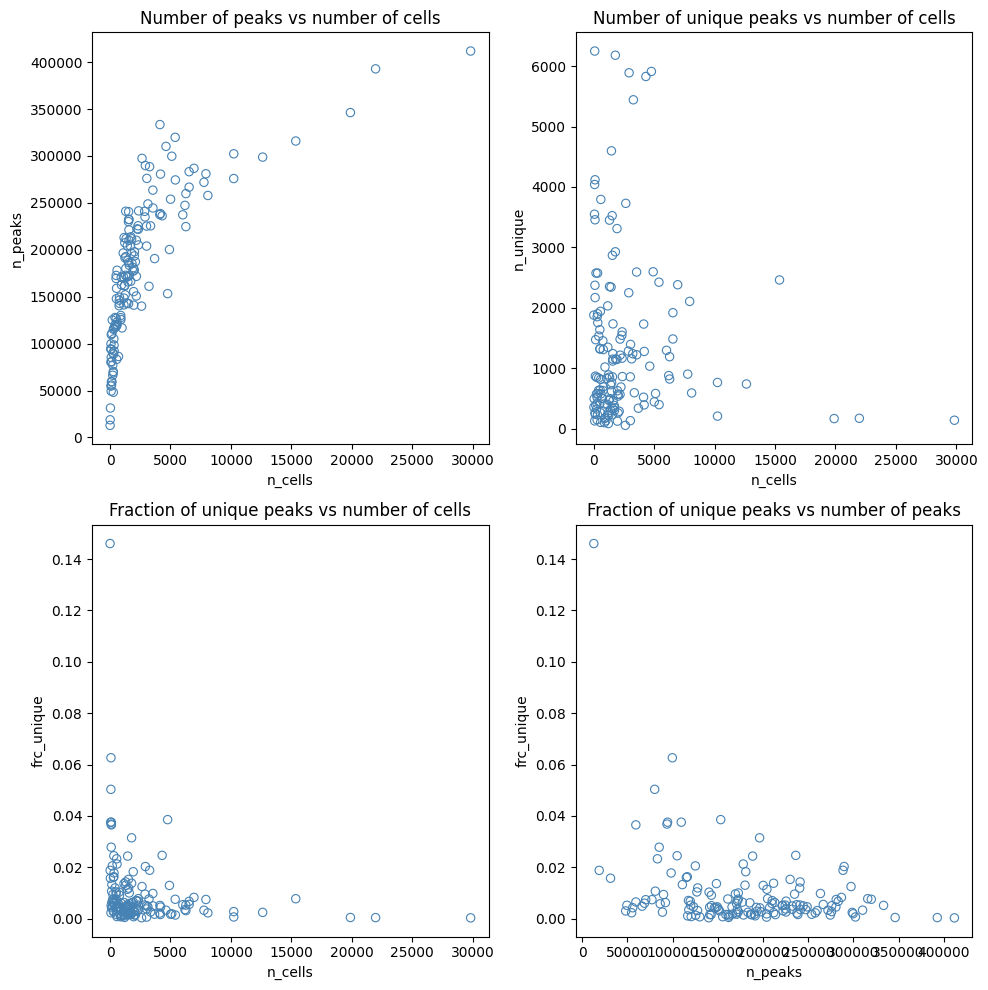

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

scatter_kws = dict(facecolors='none', edgecolors='steelblue', linewidth=0.8)

sns.scatterplot(peak_counts, x="n_cells", y="n_peaks", ax=axes[0, 0], **scatter_kws)
axes[0, 0].set_title("Number of peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_cells", y="n_unique", ax=axes[0, 1], **scatter_kws)
axes[0, 1].set_title("Number of unique peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_cells", y="frc_unique", ax=axes[1, 0], **scatter_kws)
axes[1, 0].set_title("Fraction of unique peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_peaks", y="frc_unique", ax=axes[1, 1], **scatter_kws)
axes[1, 1].set_title("Fraction of unique peaks vs number of peaks")

plt.tight_layout()

## LVL3 peaks

In [22]:
key = "lvl3"

Let's take a look at the distribution of number of cells for cell types

/tmp/ipykernel_3798743/1622440495.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


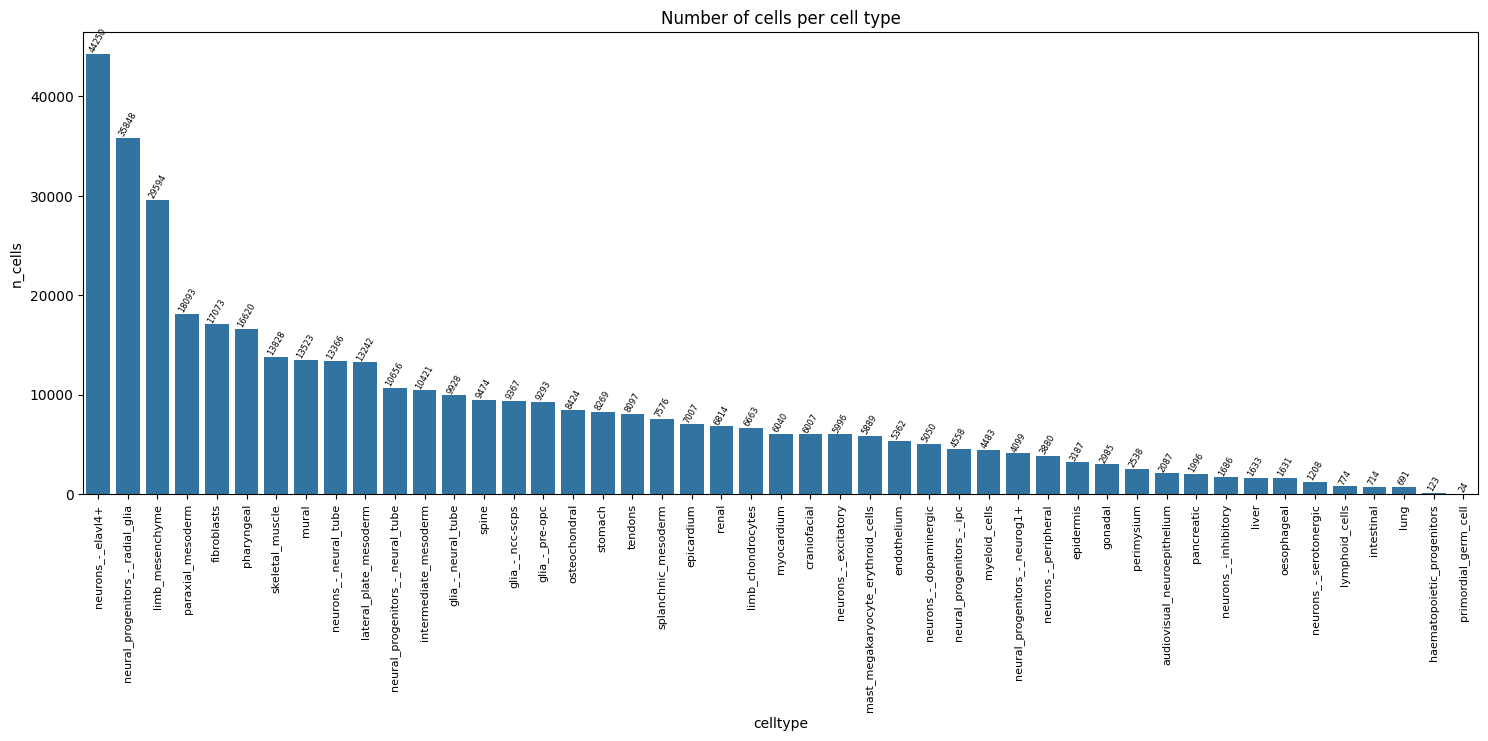

In [23]:
fig, ax = plt.subplots(figsize=(18, 6))
cell_counts = annotations[key].celltype.str.replace(" ", "_").str.lower().value_counts().to_frame(name="n_cells")

sns.barplot(cell_counts, x=cell_counts.index, y="n_cells", ax=ax)
ax.set_title("Number of cells per cell type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.bar_label(ax.containers[0], fontsize=6, rotation=60);
plt.show()

I want to take a look at peaks combined from several cell types

In [24]:
celltypes = set(','.join(peaks[key]["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).to_list()).split(","))

In [25]:
peaks[key]["celltypes"] = peaks[key]["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).apply(lambda x: ",".join(set(x.split(","))))
peaks[key]["ct_count"] = peaks[key]["celltypes"].apply(lambda x: int(len(set(x.split(",")))))
peaks[key].head()

,Chromosome,Start,End,Name,Score,Strand,celltypes,ct_count
0,chr1,804672,805172,spine_peak_4,1.514268,.,spine,1
1,chr1,833168,833668,oesophageal_peak_6,0.670822,.,oesophageal,1
2,chr1,833695,834195,mast_megakaryocyte_erythroid_cells_peak_8,0.143946,.,mast_megakaryocyte_erythroid_cells,1
3,chr1,841148,841648,mast_megakaryocyte_erythroid_cells_peak_9a,0.270618,.,mast_megakaryocyte_erythroid_cells,1
4,chr1,841674,842174,mast_megakaryocyte_erythroid_cells_peak_9b,0.305165,.,mast_megakaryocyte_erythroid_cells,1


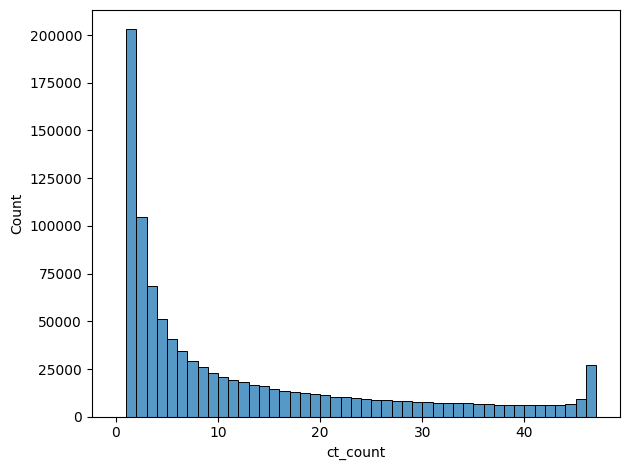

In [26]:
sns.histplot(peaks[key].ct_count, bins=np.arange(0, 48, 1))
plt.tight_layout()

In [27]:
print(f"Number of peaks in {key} that are present in 1 cell type: {(peaks[key]['ct_count'] == 1).sum()}")
print(f"Number of peaks in {key} that are present in 3 or fewer cell types: {(peaks[key]['ct_count'] <= 3).sum()}")
print(f"Number of peaks in {key} that are present in more than 3 cell types: {(peaks[key]['ct_count'] > 3).sum()}")

Number of peaks in lvl3 that are present in 1 cell type: 202962
Number of peaks in lvl3 that are present in 3 or fewer cell types: 375871
Number of peaks in lvl3 that are present in more than 3 cell types: 590953


Let's take a look at number peaks per celltype

In [28]:
from collections import Counter
import itertools

# create a flat list of all cell types and count the number of peaks per cell type
flat = list(itertools.chain.from_iterable([x.split(",") for x in peaks[key]["celltypes"].tolist()]))
counts = Counter(flat)
peak_counts = pd.DataFrame(counts.most_common(), columns=["celltype", "n_peaks"]).set_index("celltype")

# count the number of peaks that are unique to each cell type (i.e. present in only 1 cell type)
unique_peak_counts = peaks[key][peaks[key]['ct_count'] == 1].celltypes.value_counts().to_frame(name="n_unique")

peak_counts = pd.concat([peak_counts, unique_peak_counts, cell_counts], axis=1).fillna(0).reset_index(names="celltype").sort_values("n_cells", ascending=False)
peak_counts["frc_unique"] = peak_counts["n_unique"] / peak_counts["n_peaks"]
peak_counts

,celltype,n_peaks,n_unique,n_cells,frc_unique
0,neurons_-_elavl4+,405271,531,44250,0.001310
6,neural_progenitors_-_radial_glia,326924,3943,35848,0.012061
3,limb_mesenchyme,341449,3041,29594,0.008906
12,paraxial_mesoderm,302358,3775,18093,0.012485
4,fibroblasts,329482,1137,17073,0.003451
16,pharyngeal,295926,1659,16620,0.005606
2,skeletal_muscle,353010,11174,13828,0.031653
11,mural,307728,1392,13523,0.004523
10,neurons_-_neural_tube,309475,6607,13366,0.021349
14,lateral_plate_mesoderm,300182,2909,13242,0.009691


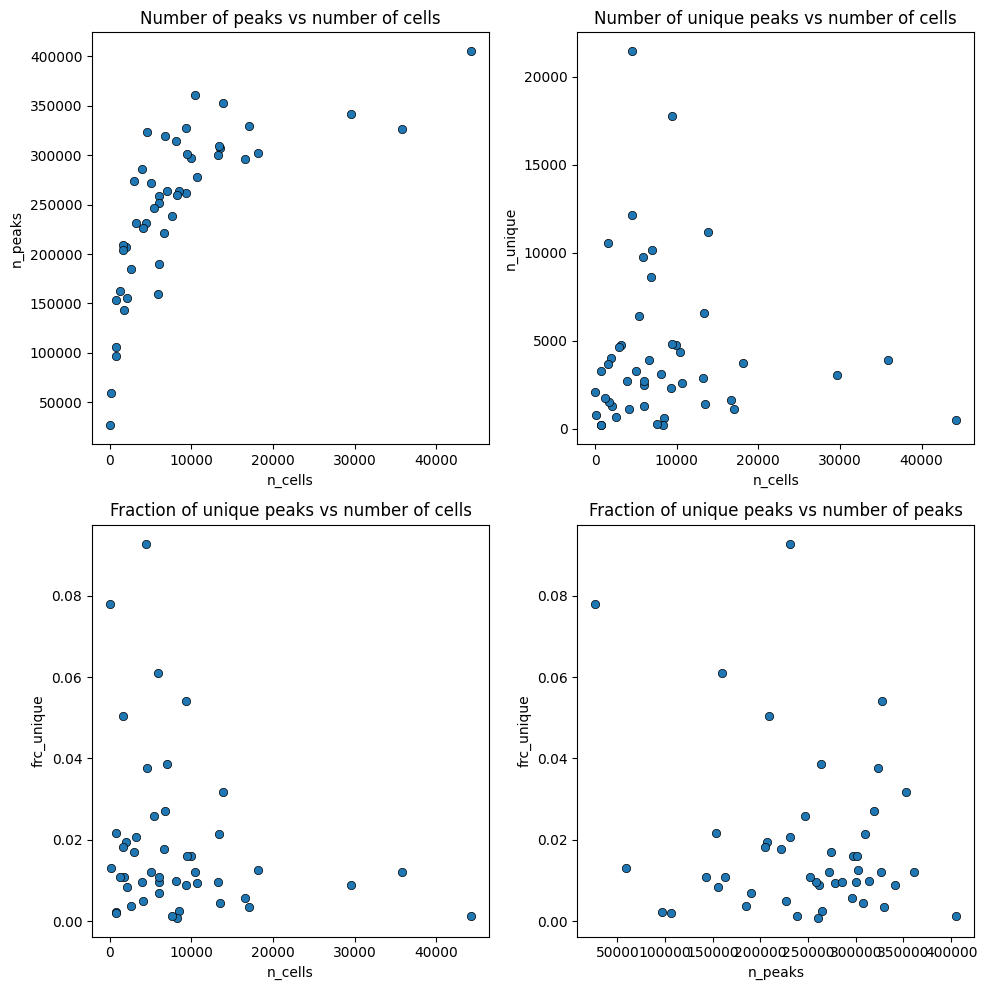

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

scatter_kws = dict(edgecolors='black', linewidth=0.5)

sns.scatterplot(peak_counts, x="n_cells", y="n_peaks", ax=axes[0, 0], **scatter_kws)
axes[0, 0].set_title("Number of peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_cells", y="n_unique", ax=axes[0, 1], **scatter_kws)
axes[0, 1].set_title("Number of unique peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_cells", y="frc_unique", ax=axes[1, 0], **scatter_kws)
axes[1, 0].set_title("Fraction of unique peaks vs number of cells")

sns.scatterplot(peak_counts, x="n_peaks", y="frc_unique", ax=axes[1, 1], **scatter_kws)
axes[1, 1].set_title("Fraction of unique peaks vs number of peaks")

plt.tight_layout()

## Peak overlap descr

### Missing peaks

In [30]:
peaks["lvl5"].head()

,Chromosome,Start,End,Name,Score,Strand,celltypes,ct_count
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,radial_glia_diencephalon,1
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,wolffian_duct_epithelium,1
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,megakaryocyte_progenitor,1
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,megakaryocyte_progenitor,1


In [31]:
celltypes = set(','.join(peaks["lvl5"]["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).to_list()).split(","))

In [32]:
peaks["lvl5"]["ct_count"] = peaks["lvl5"]["Name"].str.replace(r'_peak_\d+[a-z]*', '', regex=True).apply(lambda x: int(len(set(x.split(",")))))
peaks["lvl5"].head()

,Chromosome,Start,End,Name,Score,Strand,celltypes,ct_count
0,chr1,794695,795195,radial_glia_diencephalon_peak_3,0.097895,.,radial_glia_diencephalon,1
1,chr1,804676,805176,fibroblast_progenitors_pdgfra+mustn1+ptch1+_peak_4,1.806895,.,fibroblast_progenitors_pdgfra+mustn1+ptch1+,1
2,chr1,833037,833537,"wolffian_duct_epithelium_peak_4a,wolffian_duct_epithelium_peak_4b",1.811358,.,wolffian_duct_epithelium,1
3,chr1,833658,834158,megakaryocyte_progenitor_peak_11,0.182943,.,megakaryocyte_progenitor,1
4,chr1,841673,842173,"megakaryocyte_progenitor_peak_12a,megakaryocyte_progenitor_peak_12b",0.476959,.,megakaryocyte_progenitor,1


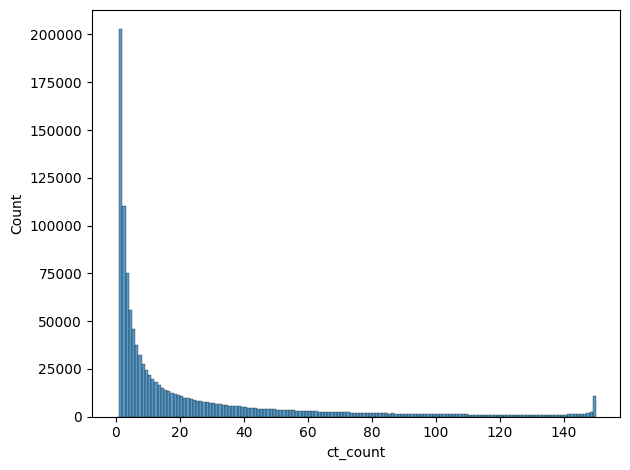

In [33]:
sns.histplot(peaks["lvl5"].ct_count, bins=np.arange(0, 151, 1))
plt.tight_layout()

In [34]:
peaks["lvl5"].Name

0                            radial_glia_diencephalon_peak_3
1          fibroblast_progenitors_pdgfra+mustn1+ptch1+_pe...
2          wolffian_duct_epithelium_peak_4a,wolffian_duct...
3                           megakaryocyte_progenitor_peak_11
4          megakaryocyte_progenitor_peak_12a,megakaryocyt...
                                 ...                        
1142052    intestinal_mesothelium_peak_48539,myofibroblas...
1142053    v0_interneuron_peak_148679a,v0_interneuron_pea...
1142054    pre-opc_hindbrain_peak_104908b,pre-opc_hindbra...
1142055    fibroblast_progenitors_pdgfra+zic1+fibin+_peak...
1142056    dl5_neuron_peak_85581,radial_glia_peak_144740,...
Name: Name, Length: 1142057, dtype: object